In [1]:
# importing the required libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# importing dataset
import kagglehub
path = kagglehub.dataset_download("fatemehmehrparvar/lung-disease")
data_dir = path + "/Lung X-Ray Image/Lung X-Ray Image"
print("Dataset Path:", data_dir)

Using Colab cache for faster access to the 'lung-disease' dataset.
Dataset Path: /kaggle/input/lung-disease/Lung X-Ray Image/Lung X-Ray Image


In [3]:
# transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# loading the dataset
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

num_classes = len(full_dataset.classes)

Classes: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Total images: 3475


In [5]:
# train-test split
from torch.utils.data import random_split, DataLoader

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
# resnet model
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, num_classes)
)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

In [8]:
num_epochs = 15
best_acc = 0

train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):

    # Training
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_list.append(train_acc)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    # saving the best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_traditional_model.pth")
        print("Best model saved!")

Epoch 1: Loss=30.2003, Train Acc=84.62%, Val Acc=91.55%
Best model saved!
Epoch 2: Loss=19.2669, Train Acc=90.62%, Val Acc=92.90%
Best model saved!
Epoch 3: Loss=19.1247, Train Acc=90.25%, Val Acc=91.94%
Epoch 4: Loss=15.3821, Train Acc=92.80%, Val Acc=93.67%
Best model saved!
Epoch 5: Loss=13.3501, Train Acc=93.46%, Val Acc=90.40%
Epoch 6: Loss=13.9579, Train Acc=93.09%, Val Acc=91.94%
Epoch 7: Loss=14.0180, Train Acc=93.26%, Val Acc=91.55%
Epoch 8: Loss=12.5322, Train Acc=93.83%, Val Acc=94.63%
Best model saved!
Epoch 9: Loss=14.0684, Train Acc=92.76%, Val Acc=94.43%
Epoch 10: Loss=10.8527, Train Acc=94.41%, Val Acc=92.13%
Epoch 11: Loss=11.7205, Train Acc=94.28%, Val Acc=91.55%
Epoch 12: Loss=11.6147, Train Acc=94.12%, Val Acc=93.67%
Epoch 13: Loss=10.6787, Train Acc=95.11%, Val Acc=91.17%
Epoch 14: Loss=11.8822, Train Acc=93.59%, Val Acc=92.51%
Epoch 15: Loss=9.0495, Train Acc=95.60%, Val Acc=92.51%


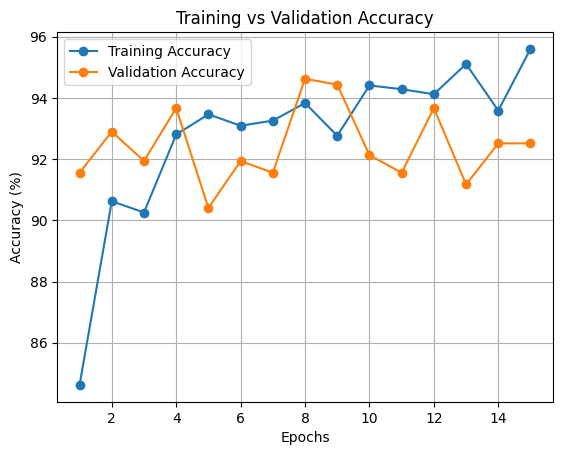

In [13]:
# training vs validation accuracy bar graph
import matplotlib.pyplot as plt
epochs = range(1, len(train_acc_list) + 1)
plt.figure()
plt.plot(epochs, train_acc_list, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc_list, marker='o', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [9]:
# testing
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


 Final Test Accuracy: 91.57088122605363

 Classification Report:

                 precision    recall  f1-score   support

   Lung_Opacity       0.89      0.89      0.89       166
         Normal       0.88      0.90      0.89       201
Viral Pneumonia       0.99      0.97      0.98       155

       accuracy                           0.92       522
      macro avg       0.92      0.92      0.92       522
   weighted avg       0.92      0.92      0.92       522


 Confusion Matrix:

[[147  19   0]
 [ 19 181   1]
 [  0   5 150]]


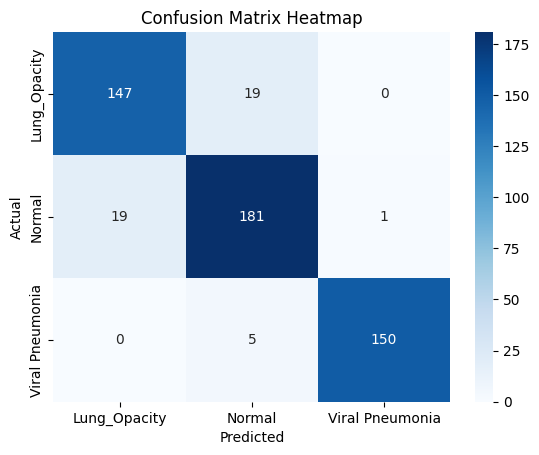

In [12]:
# report
accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100

print("\n Final Test Accuracy:", accuracy)

print("\n Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

print("\n Confusion Matrix:\n")
print(confusion_matrix(all_labels, all_preds))

# heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()